# Assignment 2 - Group 16.

- Authors: s234820, s234832, s234855

**GitHub link:** https://github.com/Vaksth/02467_CSS_assignments

\
**Contributions:**

- *Part 1: Mixing Patterns and Assortativity* code by s234855. s234820 contributed substantially by fixing severe bugs.
    - *Part 5* discussion by s234855.
- *Part 2: TF-IDF* code by s234820 and s234832.
    - *Exercise 1.1* by s234832.
    - *Exercise 1.3 text* by s234820.
    - *Exercise 2* Comment by s234820.
    - *Exercise 3* discussion by s234820.

*Overall, all group members contributed well to the project.!*

In [1]:
from collections import defaultdict
import networkx as nx
import pandas as pd
import ast
from networkx.readwrite import json_graph
import json
import numpy as np
from collections import Counter, defaultdict
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from datetime import datetime
import random

# Exercise 1: Mixing Patterns and Assortativity

>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>
> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>
> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.
>
> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.
> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 
>
> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    



### Part 1: Assortativity Coefficient

In [2]:
# Import Week 4 network
with open("graph.json") as f:
    data = json.load(f)

G = json_graph.node_link_graph(data, edges='edges')

lcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc_nodes).copy()

# Calculate the 'number of edges between nodes of the same type'
same_country_edges = [
    (u, v) # (nodeID1, nodeID2)
    for u, v in G.edges()
    if G.nodes[u]["country_code"] == G.nodes[v]["country_code"]
]

# Calculate the 'expected number of edges between nodes of the same type'
deg_by_country = {}
for node in G.nodes():
    country = G.nodes[node]["country_code"]
    deg_by_country[country] = deg_by_country.get(country, 0) + G.degree(node)

print(deg_by_country)
print("Sum =", sum(deg_by_country.values()))

# Calculate the Associativity Coefficient
e = len(same_country_edges) / len(G.edges())

tot_stubs = sum(deg_by_country.values())
a = sum((k / tot_stubs) ** 2 for k in deg_by_country.values())

r = (e - a) / (1 - a)
print("r =", r)

{'CN': 15430, 'SG': 525, 'Unknown': 21308, 'NL': 3984, 'US': 33088, 'KR': 1292, 'GB': 8117, 'IT': 5530, 'AU': 2953, 'DE': 8176, 'FI': 828, 'HK': 437, 'CZ': 113, 'SE': 1310, 'MX': 620, 'IR': 144, 'MO': 55, 'FR': 2467, 'ES': 1742, 'DK': 945, 'CH': 2160, 'BR': 755, 'CA': 2225, 'AT': 942, 'IN': 1007, 'VN': 290, 'BE': 673, 'CY': 53, 'IL': 647, 'LK': 61, 'CO': 115, 'SI': 134, 'RO': 81, 'AE': 263, 'PL': 378, 'EG': 53, 'TW': 363, 'QA': 85, 'DO': 10, 'UY': 13, 'JP': 1206, 'NO': 352, 'NZ': 206, 'ID': 114, 'SS': 54, 'BG': 53, 'ZA': 263, 'MK': 73, 'PT': 308, 'CL': 247, 'PH': 118, 'MA': 55, 'IE': 364, 'RU': 138, 'GR': 222, 'UZ': 3, 'UA': 33, 'ET': 22, 'HU': 417, 'BD': 115, 'KE': 25, 'MY': 97, 'AR': 82, 'SK': 41, 'BO': 25, 'TR': 85, 'BY': 38, 'LV': 21, 'SR': 11, 'RS': 32, 'EE': 93, 'IS': 6, 'SA': 69, 'LU': 18, 'BA': 3, 'PK': 99, 'EC': 18, 'NP': 5, 'GW': 12, 'HR': 52, 'BZ': 8, 'UG': 11, 'GH': 3, 'MW': 3, 'PE': 33, 'MT': 6, 'LT': 8, 'CR': 9, 'KH': 10, 'MD': 6, 'LB': 27, 'TH': 7, 'VE': 9, 'NG': 16, 'FJ

### Part 2: Configuration model

In [3]:
def sort_edge(edge):
    return tuple(sorted(edge))

def double_edge_swap(G_original, max_swaps=2000, seed=None):
    rng = random.Random(seed)

    edges = [sort_edge(e) for e in G_original.edges()]
    edge_set = set(edges)
    m = len(edges)

    swaps = 0

    for _ in range(max_swaps):
        while True:
            i, j = rng.sample(range(m), 2)
            e1 = edges[i]
            e2 = edges[j]

            u, v = e1
            x, y = e2

            # reject shared-node cases
            if len({u, v, x, y}) < 4:
                continue

            # choose one of the two valid undirected rewirings
            if rng.random() < 0.5:
                ne1 = sort_edge((u, y))
                ne2 = sort_edge((x, v))
            else:
                ne1 = sort_edge((u, x))
                ne2 = sort_edge((v, y))

            # avoid self-loops or duplicate new edges
            if ne1[0] == ne1[1] or ne2[0] == ne2[1]:
                continue
            if ne1 == ne2:
                continue

            # allow replacing the old edges themselves, but block all other duplicates
            if (ne1 in edge_set and ne1 not in {e1, e2}) or (ne2 in edge_set and ne2 not in {e1, e2}):
                continue

            break

        # update set
        edge_set.remove(e1)
        edge_set.remove(e2)
        edge_set.add(ne1)
        edge_set.add(ne2)

        # update list in place
        edges[i] = ne1
        edges[j] = ne2

        swaps += 1

    # rebuild graph once
    G = nx.Graph()
    G.add_nodes_from(G_original.nodes(data=True))
    G.add_edges_from(edges)

    if dict(G_original.degree()) != dict(G.degree()):
        raise ValueError("Degree sequence changed!")

    return G

### Ex1 - Part 3: Analyzing Assortativity in Random Networks

In [4]:
# Function to calculate assortativity of a networkx graph
def assortativity_calc(G):

    # Calculate the 'number of edges between nodes of the same type'
    same_country_edges = [
        (u, v) # (nodeID1, nodeID2)
        for u, v in G.edges()
        if G.nodes[u]["country_code"] == G.nodes[v]["country_code"]
    ]


    # Calculate the 'expected number of edges between nodes of the same type'
    deg_by_country = {}

    for node in G.nodes():
        country = G.nodes[node]["country_code"]
        deg_by_country[country] = deg_by_country.get(country, 0) + G.degree(node)


    # Calculate the Associativity Coefficient
    e = len(same_country_edges) / len(G.edges())

    tot_stubs = sum(deg_by_country.values())
    a = sum((k / tot_stubs) ** 2 for k in deg_by_country.values())

    r = (e - a) / (1 - a)
    return r

In [5]:
ass_list = []
graphs = []

n_models = 100
n_swaps = 10 * G.number_of_edges()

for i in tqdm(range(n_models)):
    # Start from the original graph each time
    G_rand = double_edge_swap(G, max_swaps=n_swaps, seed=i)

    ass = assortativity_calc(G_rand)
    ass_list.append(ass)
    graphs.append(G_rand)

# Save the assortativity values
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(timestamp)

with open(f"ass_list_{timestamp}.pkl", "wb") as f:
    pickle.dump(ass_list, f)

# Optional: also save the 100 randomized graphs
with open(f"random_graphs_{timestamp}.pkl", "wb") as f:
    pickle.dump(graphs, f)

100%|██████████| 100/100 [11:48<00:00,  7.09s/it]


2026-04-07_22-23-02


In [6]:
# Load the assortative coefficient list for the 100 random networks
with open(f"ass_list_{timestamp}.pkl", "rb") as f:
    ass_list = pickle.load(f)

ass_list[0:10]

[0.0019775288806844773,
 0.0004162532748108965,
 -0.00026336081245173005,
 0.004971504454300922,
 -0.001181758227671506,
 0.002602039123033935,
 -0.0007592954166704077,
 0.000636668654463635,
 0.0005999327578548452,
 0.00032441353328890616]

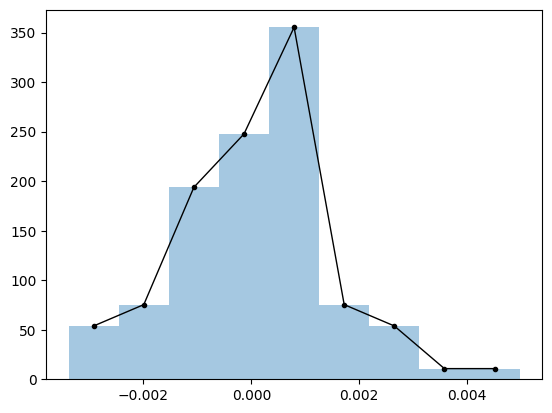

In [7]:
## Linear spacing X
citations = ass_list

bins = np.linspace(min(ass_list), max(ass_list), 10)

hist, edges = np.histogram(citations, bins=bins, density=True)
x = (edges[1:]+edges[:-1])/2
width=bins[1]-bins[0]

fig, ax = plt.subplots()
ax.bar(x, hist, width=width, alpha=0.4)
ax.plot(x, hist, marker='.', color='k', linewidth='1')

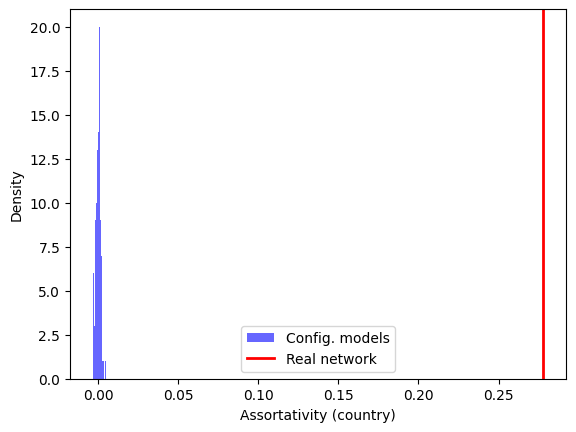

In [8]:
r_obs = assortativity_calc(G)  # original network

plt.hist(ass_list, bins=15, alpha=0.6, label="Config. models", color="blue")
plt.axvline(r_obs, color='red', linewidth=2, label='Real network')
plt.xlabel("Assortativity (country)")
plt.ylabel("Density")
plt.legend()

The distance between the configuration models distribution and the observed assortativity (Real network) is very large, suggesting that connections within the same country are significantly higher than random chance.

### Part 4: Assortativity by Degree

In [9]:
# Get degrees
deg = dict(G.degree())

# Lists of degrees at each end of every edge
ku = []
kv = []

for u, v in G.edges():
    ku.append(deg[u])
    kv.append(deg[v])

ku = np.array(ku)
kv = np.array(kv)

# Compute means
mean_ku = ku.mean()
mean_kv = kv.mean()
mean_ku_kv = (ku * kv).mean()
mean_ku2 = (ku ** 2).mean()
mean_kv2 = (kv ** 2).mean()

# Apply the formula
numerator = mean_ku_kv - mean_ku * mean_kv
denominator = np.sqrt( (mean_ku2 - mean_ku ** 2) * (mean_kv2 - mean_kv ** 2) )

r = numerator / denominator
print(r)

0.02332465082248204


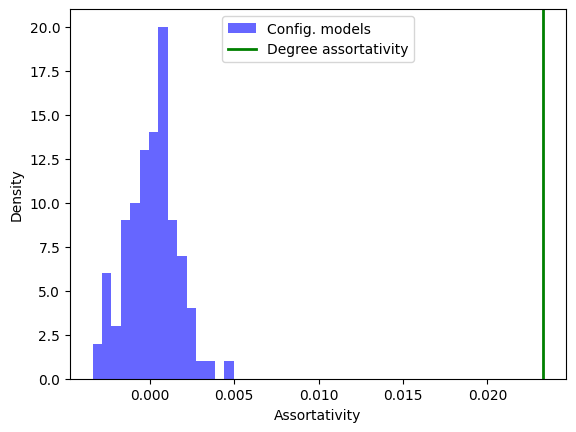

In [10]:
r_obs = assortativity_calc(G)  # original network
r_deg = r

plt.hist(ass_list, bins=15, alpha=0.6, label="Config. models", color="blue")
# plt.axvline(r_obs, color='red', linewidth=2, label='Real network')
plt.axvline(r_deg, color='green', linewidth=2, label='Degree assortativity')
plt.xlabel("Assortativity")
plt.ylabel("Density")
plt.legend()

- The *distance* from the config models to the degree assortativity means that:
    - If scientists kept the same number of collaborators but chose them at random, there would be no systematic preference for linking to similar‑degree scientists.

- That the degree assortativity is *positive* means that:
    - Scientists slightly prefer to collaborate with other scientists of similar degree.


That the degree assortativity falls far outside the near‑zero range produced by the configuration‑model networks suggests that, even if scientists kept the same number of collaborators but chose them at random, we would not observe this level of assortativity. That the degree assortativity is slightly positive indicates a subtle tendency for social scientists to preferentially collaborate with similar-degree social scientists.

### Part 5: Reflection questions

- **7. Assortativity by degree. Were the results of the degree assortativity in line with your expectations? Why or why not?**
    The results are in line with our expectation that prominent researchers will more often work with other prominent researchers and similarly for the less prominent ones. However, we expected this assortativity to be somewhat stronger than the observed value (r ≈ 0.03). In conclusion, the relatively weak degree assortativity suggests that assortative mixing by degree is weaker by nature compared to attribute assortativity (e.g., country), as collaboration networks are influenced by many factors beyond degree alone.

- **8. Edge flipping. In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?**
    - To make the edge-flipping as random as the flip of a coin to avoid introducing further bias into the model. This prevents systematic bias that could arise from always rewiring edges in the same orientation.

- **9. Distribution of assortativity in random networks. Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.**
    - The *degree assortativity* values observed in the random networks generated using the configuration model are tightly clustered around zero, with most values being slightly negative and only small variation across networks. The distribution is narrow, indicating that the randomized networks exhibit little to no systematic assortative mixing by degree.
    - The use of repeated edge flipping further ensures unbiased randomization by allowing the network to explore different valid configurations while preserving node degrees. Randomly flipping edges prevents systematic rewiring patterns and helps ensure that all degree‑preserving networks are sampled approximately uniformly.
    - As expected, the configuration model and edge flipping lead to a null distribution centered near zero. This confirms that the configuration model provides an appropriate baseline for assessing whether degree assortativity in the real network reflects genuine structure rather than randomness.

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?
> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).
> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?
> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

## Exercise 1

### Exercise 1.1

TF-IDF
 is a way to measure how important a word is in a document, relative to a collection of documents.
It boosts words that are frequent in one document but rare across all documents. So a better verision of bag of words.

TF
 is the term frequency, how often a word appears in a document

IDF
 is the inverse document frequency so how rare the word is across documents.

### Exercise 1.2

In [11]:
authors_communities = pd.read_csv("datasets/author_community_degree.csv")
abstract_df = pd.read_csv("datasets/abstract_df_with_collocations.csv")
D7 = pd.read_pickle("datasets/D7_2026-02-24_20-33-36_final.pkl")
D8 = pd.read_pickle("datasets/D8_2026-02-24_20-33-36_final.pkl")
D9 = pd.read_pickle("datasets/D9_2026-02-24_20-33-36_final.pkl")

print(authors_communities.columns.tolist())
print(abstract_df.columns.tolist())

authors_communities.head()
abstract_df.head()

['author', 'community', 'degree']
['id', 'title', 'abstract_inverted_index', 'text', 'tokens']


,id,title,abstract_inverted_index,text,tokens
0,W2055957857,Framing as a Theory of Media Effects,"{'Research': [0], 'on': [1], 'framing': [2, 25...",Research on framing is characterized by theore...,"['research', 'framing', 'characterized', 'theo..."
1,W2095655043,Text as Data: The Promise and Pitfalls of Auto...,"{'Politics': [0], 'and': [1, 9, 67, 96, 99, 10...",Politics and political conflict often occur in...,"['politics', 'political', 'conflict', 'often',..."
2,W2002781392,"Framing, Agenda Setting, and Priming: The Evol...","{'This': [0], 'special': [1], 'issue': [2], 'o...",This special issue of Journal of Communication...,"['special_issue', 'journal', 'communication', ..."
3,W2096974619,Structural Topic Models for Open‐Ended Survey ...,"{'Collection': [0], 'and': [1, 14, 37, 78, 97,...",Collection and especially analysis of open‐end...,"['collection', 'especially', 'analysis', 'open..."
4,W3124726575,Shifting attention to accuracy can reduce misi...,{},NaN,[]


In [12]:
# Parse authors in D8
def parse_authors(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            x = x.strip("[]")
            if not x:
                return []
            return [a.strip().strip("'").strip('"') for a in x.split(",")]
    return []

D8["authors"] = D8["authors"].apply(parse_authors)

# Parse tokens from CSV
def parse_tokens(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

abstract_df["tokens"] = abstract_df["tokens"].apply(parse_tokens)

# 1) author -> paper mapping
author_work = (
    D8[["id", "authors"]]
    .explode("authors")
    .rename(columns={"authors": "author"})
    .dropna(subset=["author"])
)

# 2) merge author -> community
df = author_work.merge(
    authors_communities[["author", "community", "degree"]],
    on="author",
    how="inner"
)

# 3) merge paper -> tokenized abstracts from CSV
df = df.merge(
    abstract_df[["id", "tokens", "title", "text"]],
    on="id",
    how="inner"
)

# 4) avoid counting same paper multiple times in same community
df = df.drop_duplicates(subset=["community", "id"]).copy()

# 5) one large document per community
community_docs = (
    df.groupby("community")["tokens"]
    .apply(lambda token_lists: [token for tokens in token_lists for token in tokens])
    .reset_index(name="community_document")
)

# optional text version
community_docs["community_text"] = community_docs["community_document"].apply(lambda x: " ".join(x))

display(community_docs.head())
print(community_docs.shape)

,community,community_document,community_text
0,0,"[system, auditing, vital, technique, collectin...",system auditing vital technique collecting sys...
1,1,"[general, aim, paper, demonstrate, significanc...",general aim paper demonstrate significance int...
2,2,"[rich, multimedia, content, including, images,...",rich multimedia content including images audio...
3,3,"[decision_makers, often, want, target, interve...",decision_makers often want target intervention...
4,4,"[complexity, defined, terms, number, component...",complexity defined terms number components nat...


(89, 3)


### Exercise 1.3

In [13]:
# Top 5 communities by number of authors
community_sizes = (
    authors_communities.groupby("community")["author"]
    .nunique()
    .sort_values(ascending=False)
)

top5_communities = community_sizes.head(5).index.tolist()

community_docs_top5 = community_docs[
    community_docs["community"].isin(top5_communities)
].copy()

def compute_tf(tokens):
    counts = Counter(tokens)
    total = sum(counts.values())
    if total == 0:
        return {}
    return {word: count / total for word, count in counts.items()}

def top_n_terms(tf_dict, n=5):
    return sorted(tf_dict.items(), key=lambda x: x[1], reverse=True)[:n]

community_docs_top5["tf"] = community_docs_top5["community_document"].apply(compute_tf)
community_docs_top5["top_5_tf"] = community_docs_top5["tf"].apply(lambda d: top_n_terms(d, n=5))

rows = []
for _, row in community_docs_top5.iterrows():
    for word, score in row["top_5_tf"]:
        rows.append({
            "community": row["community"],
            "word": word,
            "tf": score
        })

df_top5_tf = pd.DataFrame(rows)
df_top5_tf = df_top5_tf.merge(
    community_sizes.rename("n_authors").reset_index(),
    on="community",
    how="left"
)

df_top5_tf = df_top5_tf.sort_values(
    by=["n_authors", "community", "tf"],
    ascending=[False, True, False]
).reset_index(drop=True)

display(df_top5_tf)

,community,word,tf,n_authors
0,6,people,0.006762,744
1,6,data,0.005574,744
2,6,information,0.005379,744
3,6,model,0.004191,744
4,6,research,0.004169,744
5,4,data,0.006358,720
6,4,information,0.004727,720
7,4,social,0.004562,720
8,4,using,0.004355,720
9,4,based,0.004314,720


**Similarities and differences between communities**

The five largest communities share several common high-frequency terms, especially data, information, model, and social. These terms are strongly associated with computational social science and show that the communities have a common thematic foundation. However, there are also differences. Communities 6, 4, 11, and 12 appear relatively general and either method or user-oriented, while community 8 stands out as more specialized, with terms: "networks, network and dynamics" indicating a stronger focus on network analysis.

**Why are TFs not necessarily a good description of the communities?**

TF is not always a good description of a community because it highlights the most frequent words, not necessarily the most distinctive ones. In our results, common words such as data, information, and model appear in several communities, so they are frequent but not very specific. This makes TF useful for showing broad themes, but less useful for identifying what uniquely characterizes each community.

**What base logarithm did you use, and is it important?**

For IDF, we used the formula
$\mathrm{idf}(t, D)=\log\left(\frac{N}{n_t}\right)$
where $D$ is the corpus, $N$ is the number of documents and $n_t$ is the number of documents containing term $t$. In this exercise, the documents are the community-documents.
We used the natural logarithm through math.log(). The exact logarithm base is usually not important, since changing the base primarily rescales the values and does not change the ranking of the words.

### Exercise 1.4

In [14]:
# 1) Top 9 communities by number of authors
community_sizes = (
    authors_communities.groupby("community")["author"]
    .nunique()
    .sort_values(ascending=False)
)

top9_communities = community_sizes.head(9).index.tolist()

community_docs_top9 = community_docs[
    community_docs["community"].isin(top9_communities)
].copy()

# 2) TF
def compute_tf(tokens):
    term_counts = Counter(tokens)
    total_terms = len(tokens)
    if total_terms == 0:
        return {}
    return {term: count / total_terms for term, count in term_counts.items()}

community_docs_top9["tf"] = community_docs_top9["community_document"].apply(compute_tf)

# 3) IDF across the 9 community-documents
N = len(community_docs_top9)
doc_freq = defaultdict(int)

for tokens in community_docs_top9["community_document"]:
    for term in set(tokens):
        doc_freq[term] += 1

idf = {
    term: math.log((N + 1) / (df + 1)) + 1
    for term, df in doc_freq.items()
}

# 4) TF-IDF
def compute_tfidf(tf_dict, idf_dict):
    return {term: tf_value * idf_dict[term] for term, tf_value in tf_dict.items()}

community_docs_top9["tfidf"] = community_docs_top9["tf"].apply(
    lambda tf_dict: compute_tfidf(tf_dict, idf)
)

def top_n_terms(score_dict, n=10):
    return sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:n]

community_docs_top9["top_10_tf"] = community_docs_top9["tf"].apply(lambda d: top_n_terms(d, n=10))
community_docs_top9["top_10_tfidf"] = community_docs_top9["tfidf"].apply(lambda d: top_n_terms(d, n=10))


for _, row in community_docs_top9.sort_values("community").iterrows():
    community = row["community"]
    n_authors = int(community_sizes.loc[community])

    top3_authors = (
        authors_communities[authors_communities["community"] == community]
        .sort_values("degree", ascending=False)
        .head(3)[["author", "degree"]]
    )

    print("\n" + "=" * 70)
    print(f"Community {community}  |  Number of authors: {n_authors}")
    print("=" * 70)

    print("\nTop 10 TF words:")
    display(pd.DataFrame(row["top_10_tf"], columns=["word", "tf"]))

    print("Top 10 TF-IDF words:")
    display(pd.DataFrame(row["top_10_tfidf"], columns=["word", "tfidf"]))

    print("Top 3 authors by degree:")
    display(top3_authors.reset_index(drop=True))


Community 4  |  Number of authors: 720

Top 10 TF words:


,word,tf
0,data,0.006358
1,information,0.004727
2,social,0.004562
3,using,0.004355
4,based,0.004314
5,human,0.004273
6,model,0.003592
7,people,0.003385
8,use,0.003138
9,study,0.003014


Top 10 TF-IDF words:


,word,tfidf
0,data,0.006358
1,information,0.004727
2,social,0.004562
3,using,0.004355
4,based,0.004314
5,human,0.004273
6,model,0.003592
7,people,0.003385
8,use,0.003138
9,study,0.003014


Top 3 authors by degree:


...

,word,tf
0,users,0.008712
1,information,0.005760
2,data,0.005379
3,user,0.005260
4,content,0.004618
5,social,0.003880
6,study,0.003832
7,using,0.003689
8,based,0.003547
9,social_media,0.003380


Top 10 TF-IDF words:


,word,tfidf
0,users,0.008712
1,information,0.005760
2,data,0.005379
3,user,0.005260
4,content,0.004618
5,social,0.003880
6,study,0.003832
7,using,0.003689
8,based,0.003547
9,social_media,0.003380


Top 3 authors by degree:


,author,degree
0,A5081008532,101
1,A5067688305,97
2,A5072703507,97


## Exercise 2

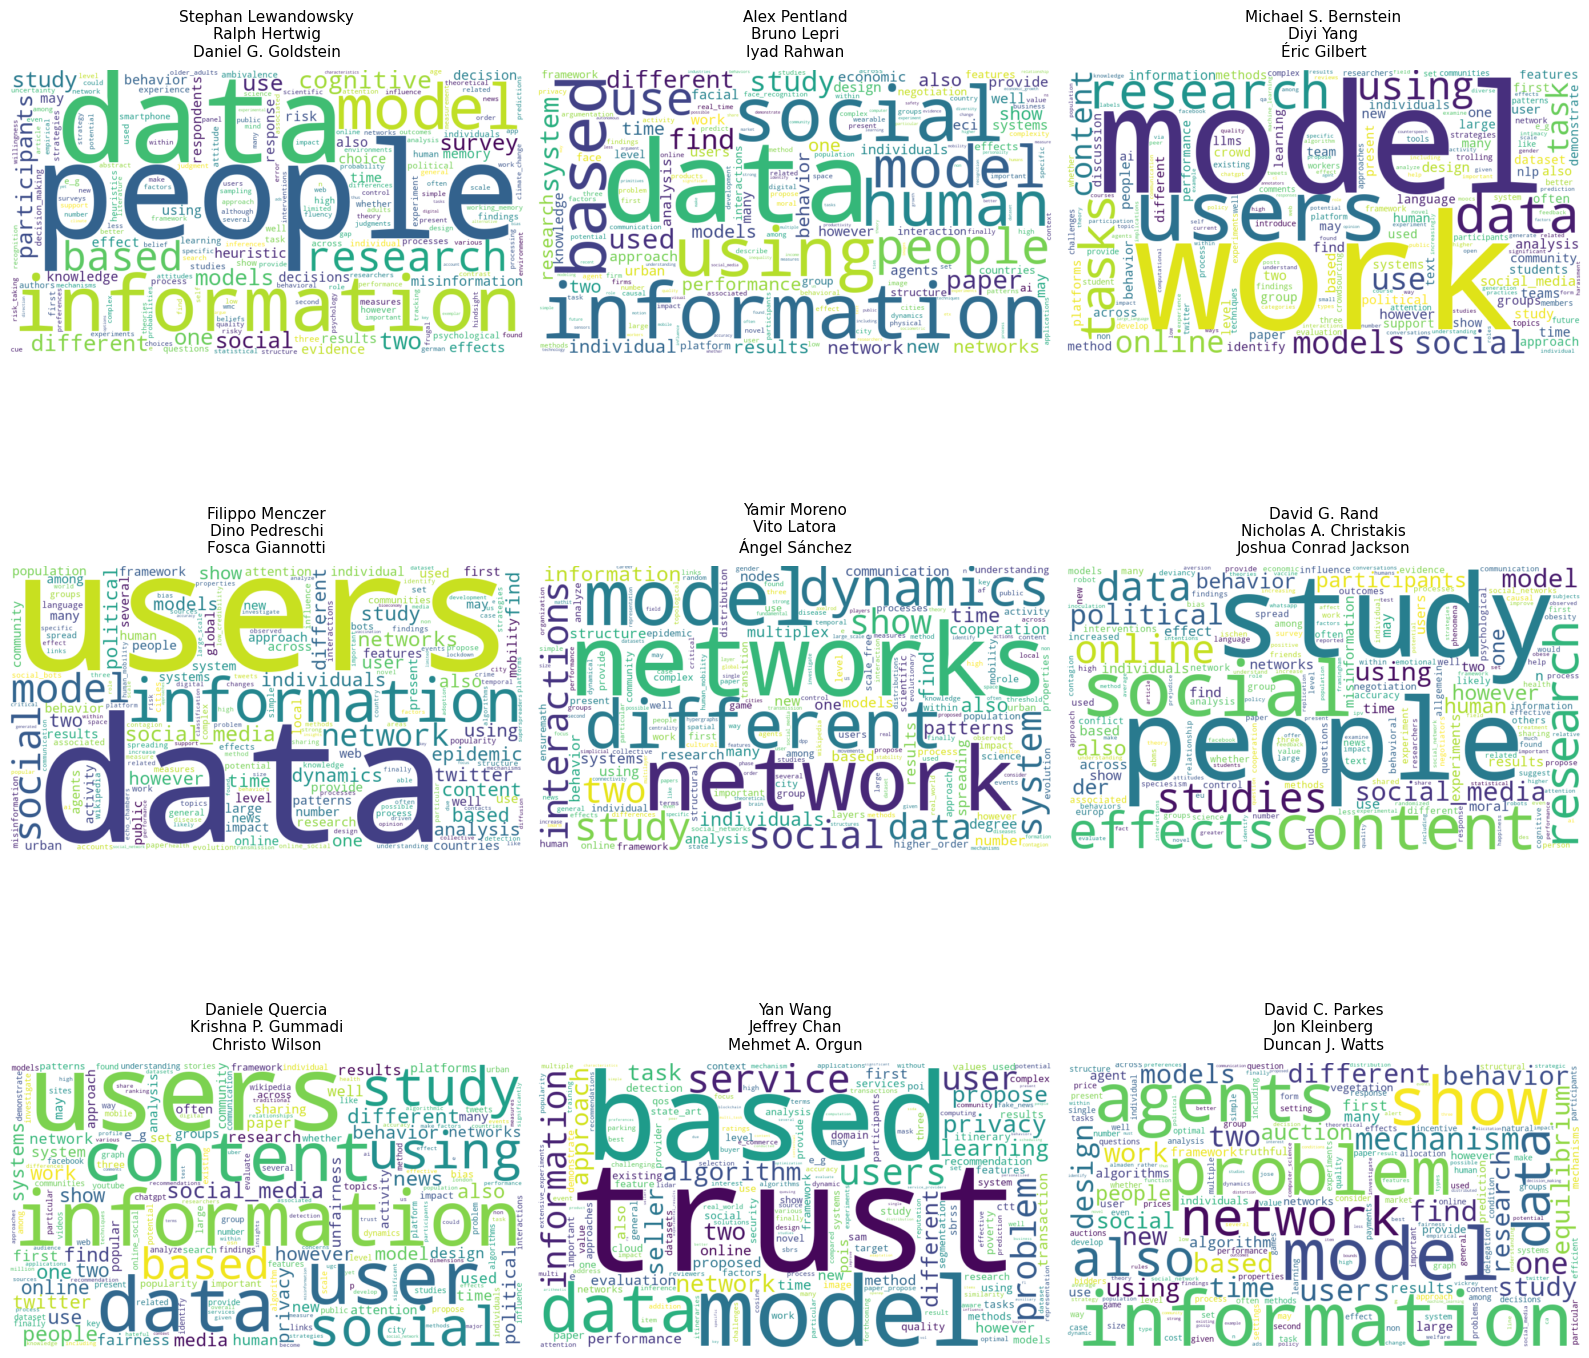

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --------------------------------------------------
# Build a mapping from author ID to author name
# D7 contains:
#   - "id"           : author ID
#   - "display_name" : human-readable author name
# --------------------------------------------------
author_id_to_name = dict(zip(D7["id"], D7["display_name"]))

# --------------------------------------------------
# Find the top 3 authors by degree within each of the
# top 9 communities, then replace author IDs with names
# --------------------------------------------------
top3_authors_dict = (
    authors_communities[authors_communities["community"].isin(top9_communities)]
    .sort_values(["community", "degree"], ascending=[True, False])
    .groupby("community")
    .head(3)
    .assign(author_name=lambda df: df["author"].map(author_id_to_name).fillna(df["author"]))
    .groupby("community")["author_name"]
    .apply(list)
    .to_dict()
)

# --------------------------------------------------
# Keep a fixed order: largest communities first
# --------------------------------------------------
top9_sorted = community_sizes.head(9).index.tolist()

# --------------------------------------------------
# Create a lookup from community ID to TF-IDF dictionary
# --------------------------------------------------
tfidf_lookup = dict(zip(community_docs_top9["community"], community_docs_top9["tfidf"]))

# --------------------------------------------------
# Create a 3x3 grid of word clouds, one for each community
# --------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()

for ax, community in zip(axes, top9_sorted):
    frequencies = tfidf_lookup[community]
    top3_authors = top3_authors_dict.get(community, [])

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        collocations=False,
        prefer_horizontal=0.9
    ).generate_from_frequencies(frequencies)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")

    # Show the top 3 author names above each word cloud
    author_text = "\n".join(top3_authors)
    ax.set_title(author_text, fontsize=11, pad=10)

# Hide any unused subplot axes
for ax in axes[len(top9_sorted):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("community_wordclouds_3x3.png", dpi=300, bbox_inches="tight")
plt.show()

**Comment on our results**

The 9 word clouds reveal distinct sub-communities within Computational Social Science:
1. Behavioral & Cognitive Science (Lewandowsky, Hertwig, Goldstein)
Words like people, information, data, misinformation, cognitive, decision, risk suggest this group focuses on human decision-making, cognitive biases, and misinformation, bridging psychology and data science.

2. Social Networks & Human Behavior (Pentland, Lepri, Rahwan)
Dominant words: human, data, social, information, network, behavior, economic. This community studies how humans behave collectively, with a strong computational/economic modeling angle.

3. AI & potentially startups (Bernstein, Yang, Gilbert)
Words like model, work, users, team, model, ai, content, online and social point toward AI related work and potenial start ups trying to gain traction online.

4. Misinformation & Social Media (Menczer, Pedreschi, Giannotti)
Data, users, social media, bots, network, information, twitter and epidemic. Seems to be a clear focus on social media and misinformation.

5. Complex Networks & Spreading Dynamics (Moreno, Latora, Sánchez)
Network, networks, dynamics, interactions, model, spreading, higher-order — a more theoretical community focusing on complex network structures and dynamics.

6. Social Experiments & Cooperation (Rand, Christakis, Jackson)
People, social, study, behavior, cooperation, political, individuals, experiments — focused on experimental social science, including cooperation and human behavior.

7. Privacy, Fairness & Social Media Analysis (Quercia, Gummadi, Wilson)
Social, data, information, users, twitter, privacy, fairness, content, political — this community investigates algorithmic fairness, privacy, and platform bias, often using social media data.

8. Recommender Systems & Trust (Wang, Chan, Orgun)
Trust, model, service, data, user, algorithm, recommendation, transaction — oriented toward trust modeling, recommender systems, and online services.

9. Mechanism Design & Algorithmic Economics (Parkes, Kleinberg, Watts)
Problem, agents, network, model, information, mechanism, equilibrium, auction, algorithm — this group sits at the intersection of economics, game theory, and computer science, studying algorithmic mechanism design and networks.

Overall conclusion: CSS is highly interdisciplinary. Sub-communities range from psychology-adjacent work (misinformation, behavior) to physics-inspired network science, to computer science (AI, algorithms, mechanisms). Common threads across nearly all clouds — data, model, information, social, network — reflect the shared computational methodology, but the specific focus words reveal fundamentally different disciplinary roots and research questions.

**Top author in each community — Do your results make sense?**

Yes, overall the results look convincing. The top authors fit the themes shown in the word clouds quite well.

For example, Stephan Lewandowsky works on cognition and misinformation and sits as the chair of cognitive psychology at the university of Bristol. This matches the cloud with words such as information, model, participants, and misinformation.

The community led by Alex Pentland is dominated by words like humans, behavior, and information. That also makes sense, as he directs the MIT Connection Science and Human Dynamics labs.

The cluster with Michael S. Bernstein shows terms such as tasks, users, and research, which fits his profile as a professor of computer science and a senior fellow at the institute for human-centered artificial intelligence

The 4th cluster with Filippo Menczer as the top author contains words like information, social_media, and network. Fitting as he is a professor of infomatics and computer science

the 5th community lead by Yamir Moreno cloud emphasizes network, dynamics, and interactions. Aligning with Morenos field, as he is responsible of the Complex Networks and Systems Group (COSNET) and a pioneering researcher in the theory of complex networks.

the 6th community lead by David G. Rand has the word people, study, research, social at the center aligning with his profile as a professor of Management Science and Brain and Cognitive Sciences at MIT

The 7th community lead by Daniele Quercia cluster is dominated by the words: cities, urban, and information, which also fits very well, since he is department head of Social Dynamics at Nokia Bell Labs Cambridge and his research has been focusing in the area of urban informatics.

The community lead by David C. Parkes contains words like problem, algorithm, mechanism, and auctions. That is also consistent with Parkes’ work in multi-agent AI and mechanism design

Overall, the online profiles of the top authors support the interpretation of the word clouds.

## Exercise 3 

Before doing this analysis, our assumption was that computational social science was mostly about running statistics on small surveys or controlled experiments, so basically traditional social science with a bit more computing power, applied to small datasets. The word clouds and TF-IDF analysis challenge that view pretty directly.

Looking at the communities, the dominant terms across almost all groups are words like “people,” “human,” “users,” “information,” and “social”, which shows that the field is not just studying humans through surveys or in controlled lab settings, but through the traces they leave at scale: social media activity, collaboration networks, and online interactions. Each community also has a pretty distinct focus, whether that is misinformation, trust, or network dynamics, which shows there is a lot more going on than just one single approach. It is human behavior studied through very different angles, at a scale traditional methods don’t reach.

In that sense, the analysis reframed computational social science as something broader and more human-centered than initially assumed.